In [1]:
%matplotlib inline

### 9.1 matplotlib 入门

为什么要用fig = plt.figure()  ax = fig.add_subplot()  而不是像py那样直接用plt.plot()?
因为plt.plot()适用于快速绘制一张图，适合简单快速绘图   
fig.add_subplot() 是面向对象接口，适用于更复杂的布局和精确控制  


何时使用 add_subplot()？  
当你需要：  

创建多个子图；  
更灵活地控制每个子图的属性；  
设置多个图的布局；  
需要在子图间共享 x 轴或 y 轴时。  
这种情况下，面向对象的 add_subplot() 方法会更有优势。  

In [247]:
import matplotlib.pyplot as plt
import random
import numpy as np
plt.rcParams['font.family'] = 'SimHei'

In [5]:
data = np.arange(10)
data

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

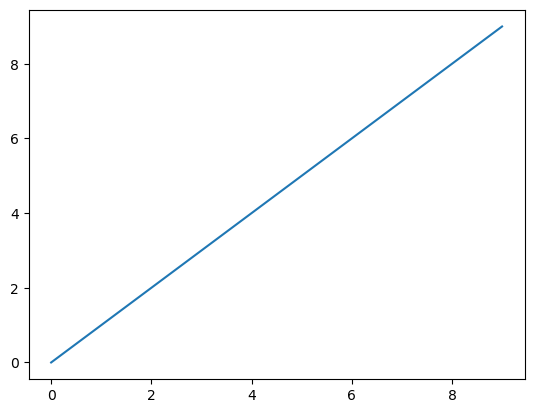

In [7]:
plt.plot(data)

#### 9.1.1 图和子图

In [7]:
# matplotlib的图像位于Figure对象中。可以用plt.figure创建一张新图：
fig = plt.figure()

<Figure size 640x480 with 0 Axes>

In [9]:
ax1 = fig.add_subplot(2, 2, 1)

这条代码指定，图像应该是2×2的（即最多4张图），且当前选中的是4张子图中的第1张（编号从1开始）。  
如果接着再创建两张子图，最终得到的结果如图9-2所示：

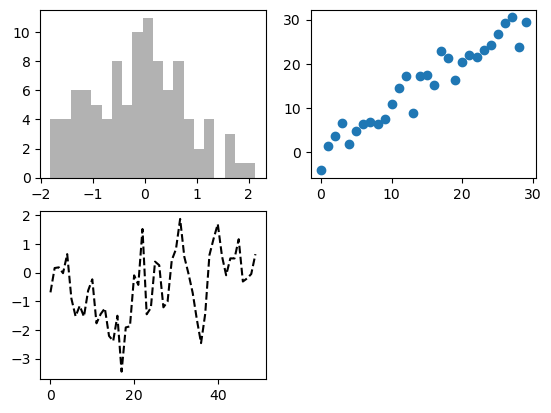

In [21]:
# jupyter 重新执行每个代码框后，图形会被重置。
# 因此，必须将所有的绘图命令放在同一个代码框中。
fig = plt.figure()   #创建新的图形对象
ax1 = fig.add_subplot(2, 2, 1)   #添加一个子图到图形中。这是一个 2x2 的网格中的第一个子图。  
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)   #fig.add_subplot返回的是AxesSubplot对象，直接调用方法实例即可在空格画图

# 线形图：
# cumsum() 累加值，后一个值是前面一个值的累加
# linestyle 有实线、虚线、点划线、点线
ax3.plot(np.random.standard_normal(50).cumsum(), color="black",    # 黑色线条
         linestyle="dashed")    # 虚线

# hist直方图 柱状图
# alpha=0.3 设置重叠图像的透明度，范围是 0 到 1，0 为完全透明，1 为完全不透明
# bins=20 将数据分为20个区间，等宽区间
ax1.hist(np.random.standard_normal(100), bins=20, color="black", alpha=0.3)

# 点图
# 30个随机数作为 x 轴数据
# x 的值加上一个标准差为 3 的随机噪声即为 y 轴的值
ax2.scatter(np.arange(30), np.arange(30) + 3 * np.random.standard_normal(30))

In [23]:
np.arange(30)

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29])

np.arange(30) 等同于 np.arange(0, 30, 1)  
start: 起始值（默认值是 0）。   
stop: 结束值（不包括在内）。  
step: 步长（默认值是 1）。   

3 * np.random.standard_normal(30) 生成一个标准正态分布的数据，并将其乘以 3，调整了噪声的幅度。  
添加的随机噪声使数据点不完全沿着直线分布，这有助于模拟实际数据中的变异性。

可以在matplotlib的文档（https://matplotlib.org）中找到各种图表类型。

为了更方便地创建网格化的子图，matplotlib提供了一个更便捷的方法plt.subplots，
它可以创建一个新的图形对象，并返回一个NumPy数组，其中包含创建好的子图对象：

array([[<Axes: >, <Axes: >, <Axes: >],
       [<Axes: >, <Axes: >, <Axes: >]], dtype=object)

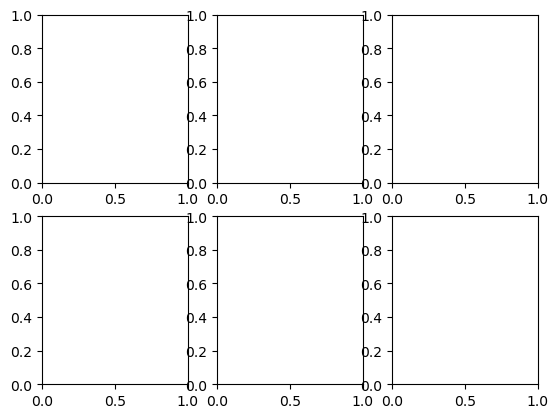

In [25]:
fig, axes = plt.subplots(2, 3)
axes

axes数组可以像二维数组那样进行索引，例如,axes[0,1]引用的是位于第1行、第2
列的子图。


还可以通过sharex和sharey指定子图应该具有相同的x轴或y轴。


在比较相同范围的数据时，这是非常实用的；否则，matplotlib会自动缩放图表的各自界限。


关于matplotlib.pyplot.subplots选项：


![jupyter](9.1.png)

![jupyter](9.2.png)

#### 调整子图周围间距
默认情况下，matplotlib会在子图周围留出边距，并在子图之间留出间距。  
间距与图像的高度和宽度有关，因此，如果（不管是通过编程还是手动使用GUI窗口）调整了图像大
小，间距也会自动调整。  

In [ ]:
# 利用Figure对象的subplots_adjust方法可以便捷地调整间距：
subplots_adjust(left=None, bottom=None, right=None, top=None,
                wspace=None, hspace=None)

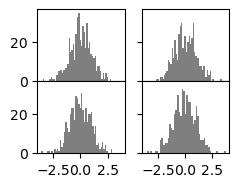

In [19]:
# wspace和hspace分别用于控制图片宽度和高度的百分比，可以用作子图之间的间距。
# fig 图形对象，用来画图，axes用于表示绘图区域，可以在区域内绘制图表
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        axes[i, j].hist(np.random.standard_normal(500), bins=50,
                        color="black", alpha=0.5)

fig.subplots_adjust(left=0.2, bottom=0.2, right=0.5, top=0.5,
                wspace=0.2, hspace=0)

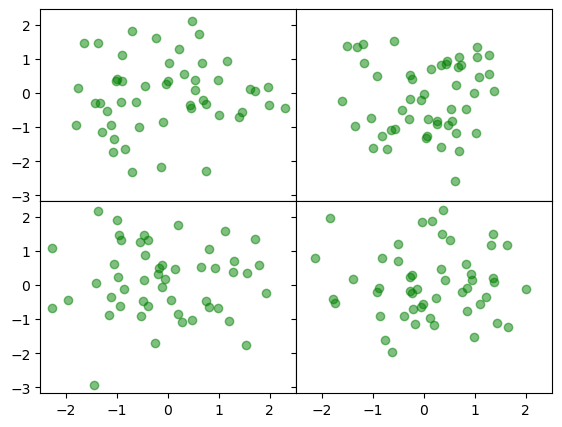

In [41]:
fig, axes = plt.subplots(2, 2, sharex=True, sharey=True)
for i in range(2):
    for j in range(2):
        #scatter只接收 x、y的值，而bins是用于直方图的
        x = np.random.standard_normal(50)
        y = np.random.standard_normal(50)
        axes[i, j].scatter(x, y, color="green", alpha=0.5)

fig.subplots_adjust(left=0.1, bottom=0.1, right=0.9, top=0.9,
                    wspace=0, hspace=0)

轴标签重叠了，需要自己设定刻度位置和刻度标签

#### 9.1.2 颜色、标记和线形
matplotlib的线型plot函数接收一组x和y坐标，还可以接收一个表示颜色和线型的参
数。

In [ ]:
# 根据x和y绘制绿色虚线
ax.plot(x, y, linestyle="--", color="green")

In [105]:
# 对于常用的颜色，可以用 16 表示，也可以查看文档
plt.plot?

Signature:
plt.plot(
    *args: 'float | ArrayLike | str',
    scalex: 'bool' = True,
    scaley: 'bool' = True,
    data=None,
    **kwargs,
) -> 'list[Line2D]'
Docstring:
Plot y versus x as lines and/or markers.

Call signatures::

    plot([x], y, [fmt], *, data=None, **kwargs)
    plot([x], y, [fmt], [x2], y2, [fmt2], ..., **kwargs)

The coordinates of the points or line nodes are given by *x*, *y*.

The optional parameter *fmt* is a convenient way for defining basic
formatting like color, marker and linestyle. It's a shortcut string
notation described in the *Notes* section below.

>>> plot(x, y)        # plot x and y using default line style and color
>>> plot(x, y, 'bo')  # plot x and y using blue circle markers
>>> plot(y)           # plot y using x as index array 0..N-1
>>> plot(y, 'r+')     # ditto, but with red plusses

You can use `.Line2D` properties as keyword arguments for more
control on the appearance. Line properties and *fmt* can be mixed.
The following two calls yie

线形图可以使用标记强调数据点。  


因为matplotlib的plot函数可以创建连续线形图、在点与点之间进行插值，因此有时可能不太容易看出真实数据点的位置。    


也可以将标记放到额外的格式选项中

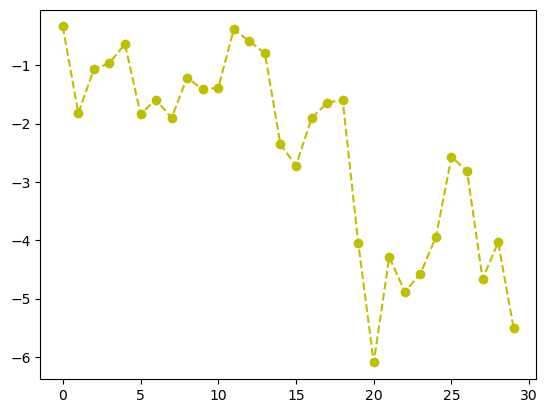

In [51]:
#创建带有标记的线条
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(np.random.standard_normal(30).cumsum(), color="y",
        linestyle="dashed", marker="o")

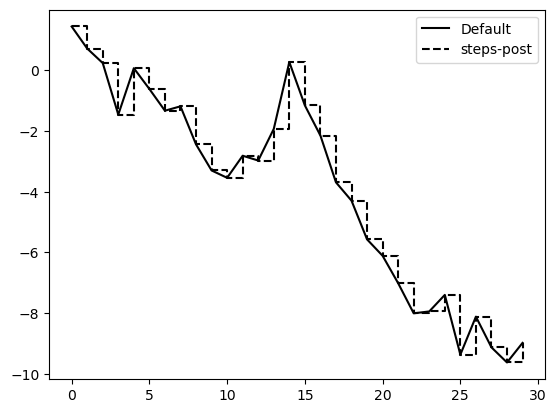

In [57]:
# 带有标记的线形图
# 在线形图中，插值数据点默认是按线性方式插入的。通过drawstyle选项修改
# 创建画图对象
fig = plt.figure()
# 创建一个子图
ax = fig.add_subplot()
# 生成随机累积数据
data = np.random.standard_normal(30).cumsum()
# 第一次随机数走向，直线绘制solid，标签为Default 
ax.plot(data, color="black", linestyle="solid", label="Default")
# 第二次随机数走向，虚线绘制，阶梯线绘图方式steps-post
# 每个数据点发生变化之后开始跳跃
ax.plot(data, color="black", linestyle="dashed",
        drawstyle="steps-post", label="steps-post")
# 显示图例以区分不同绘图样式。
ax.legend()

因为传入了 label 参数给 plot， 因此可以使用 ax.legend 创建一个图例来区分每一条线。

#### 9.1.3 刻度、标签、图例

对于大多数的图表装饰项，可以通过matplotlib轴对象的方法访问。  
主要方法有xlim、
xticks和xticklabels，它们分别控制图像范围、刻度位置和刻度标签



。其使用方式
以下两  种：
调用时不带参数，则返回当前的参数值（例如，ax.xlim（）返回当前的x轴绘图范  2第9章
调用时带参数，则设置参数值（例如，ax.xlim（[0，10]）会将x轴的围设置为
 


0~10)。
所有这些方法都是对当前或最近创建的AxesSubpl  
ot起作用的。它们各对应子图对象
上的两个方法，以xlim为例，就是ax.get_xlim和ax.s  et_xlim。

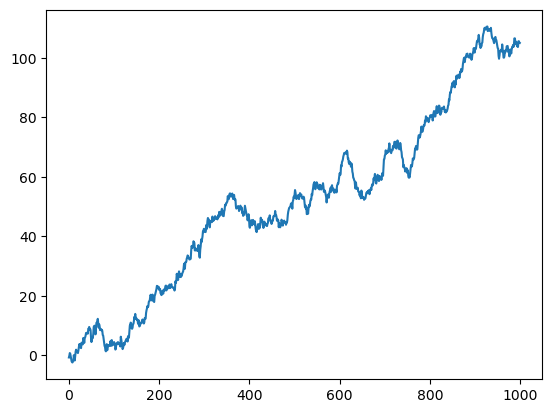

In [59]:
# 设置标题、轴标签、刻度及刻度标签
# 随机漫步
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())

set_xticks要将刻度放在数据范围中的哪些位置,默认情况下，这些位置也放置刻度标签。但可以通过set_xticklabels将任意其他值用作标签：

In [65]:
# 修改 x 轴刻度 set_xticks, set_xticklabels
ticks = ax.set_xticks([0, 250, 500, 750, 1000])
labels = ax.set_xticklabels(["one", "two", "three", "four", "five"],
                            rotation=30, fontsize=8)     # x刻度标签倾斜30度

rotation选项设定x刻度标签倾斜30度。最后，再用set_xlabel为x轴设置一个名称，并用set_title设置子图标题

In [68]:
ax.set_xlabel("Stages")

Text(0.5, 4.444444444444445, 'Stages')

In [70]:
ax.set_title("My first matplotlib plot")

Text(0.5, 1.0, 'My first matplotlib plot')

Text(0.5, 1.0, 'My first matplotlib plot')

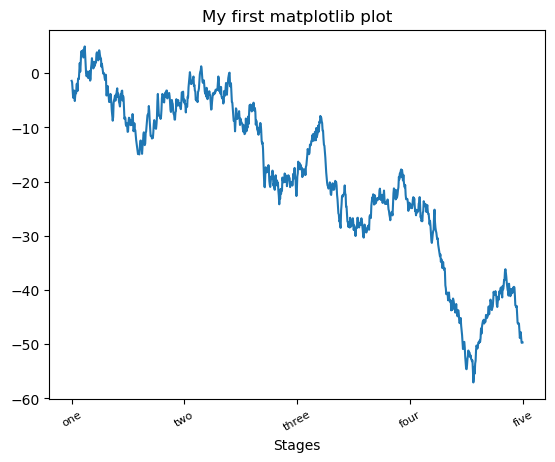

In [76]:
fig, ax = plt.subplots()
ax.plot(np.random.standard_normal(1000).cumsum())
ticks = ax.set_xticks([0, 250, 500, 750, 1000])  # 在0、250..的位置设置刻度(该位置有刻度)
labels = ax.set_xticklabels(["one", "two", "three", "four", "five"],    # 设置刻度标签
                            rotation=30, fontsize=8)    # 标签旋转30度，避免重叠，字体大小为8
ax.set_xlabel("Stages")  # x轴标签
ax.set_title("My first matplotlib plot")   # 图标标题
# 等同于 ax.set(title="My first matplotlib plot", xlabel="Stages")

#### 添加图例  
图例是另一种用于标识图表元素的重要内容。添加图例的方式有多种，最简单的是在添
加图表各组件时传人label参数：

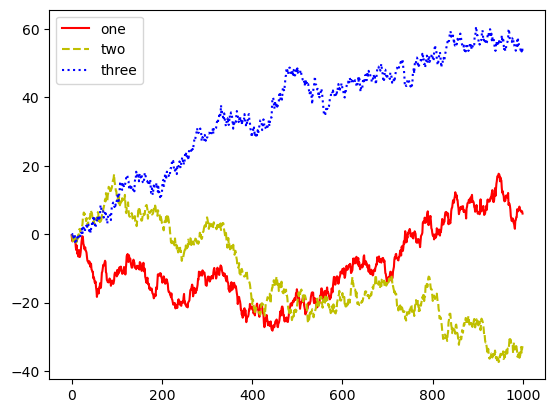

In [86]:
# 含三条线的简单图形
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="r", label="one")
ax.plot(np.random.randn(1000).cumsum(), color="y", linestyle="dashed", label="two")
ax.plot(np.random.randn(1000).cumsum(), color="blue", linestyle="dotted", label="three")
ax.legend()

standard_normal 是一个已经标准化的正态分布，其均值为0，标准差为1。  
randn 生成的是普通的正态分布的随机数，其均值和标准差取决于数据集的特性。

legend方法有多个其他的loc位置参数。更多信息请（使用ax.legend?）查看文档字符串。  



loc图例选项告诉matplotlib要将图例放在哪里。默认为"best"，它会选择最合适的位置。  
 


要从图例中去除一个或多个元素，可以不传人label或传入label="nolegend"。

In [5]:
ax.legend?

Object `ax.legend` not found.


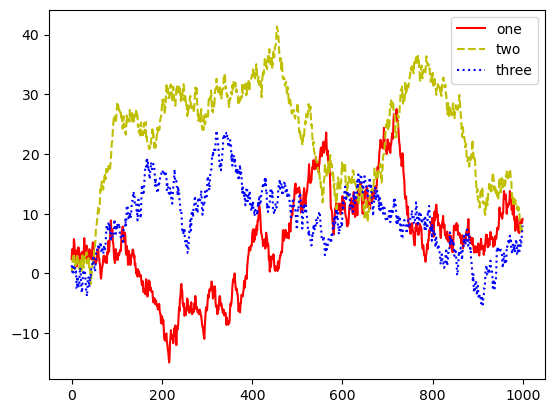

In [111]:
fig, ax = plt.subplots()
ax.plot(np.random.randn(1000).cumsum(), color="r", label="one")
ax.plot(np.random.randn(1000).cumsum(), color="y", linestyle="dashed", label="two")
ax.plot(np.random.randn(1000).cumsum(), color="blue", linestyle="dotted", label="three")
ax.legend()

#### 9.1.4 注释和绘制子图  
除了标准的绘图类型，还可以绘制一些绘图注释，注释可能包含文本、箭头或其他图形。  


注释和文字可以通过text、arrow和annotate函数进行添加。   

spx.asof() 是 pandas 中用于时间序列数据的一个方法，返回在给定日期或之前的最近一条数据。这对于处理金融数据或其他不完整的时间序列数据非常有用，因为并非所有日期都有记录。  
asof() 方法会查找与传入的日期最接近的且不晚于该日期的记录。  
例如，如果你查询的日期为2008年10月11日，但该日期没有记录，asof() 会返回离该日期最近的、在此日期之前的那条记录。  

In [153]:
# 创建示例时间序列数据
dates = pd.to_datetime(["2008-01-01", "2008-01-03", "2008-01-06"])
values = [1, 2, 3]
df = pd.DataFrame({"value": values}, index=dates)
print(df)
# 使用 asof 查询某一日期之前最近的数据
result = df.asof("2008-01-05")
print(result)

            value
2008-01-01      1
2008-01-03      2
2008-01-06      3
value    2
Name: 2008-01-05 00:00:00, dtype: int64


annotate() 是 Matplotlib 库中的一个函数，用于在图表中添加注释。这个函数可以在图表中的指定位置标记文本，并且可以用箭头指向某个数据点或位置。  
具体来说，它的主要参数包括：


xy：注释指向的坐标位置，通常是一个元组 (x, y)。  
xytext：注释文本的位置，指定为 (x, y) 元组，表示相对于数据点的位置。  
arrowprops：一个字典，用于定义箭头的样式，如颜色、宽度、箭头长度等。  
horizontalalignment 和 verticalalignment：控制注释文本的对齐方式。  
text：要显示的注释文本内容。  

xy=(date, value_at_date + 75)   箭头指向date对应的spx值加上75个单位值，向上位移75，避免重叠    



xytext=(date, value_at_date + 225)  文本指向date对应的spx值加上225个单位值，向上位移225

In [ ]:
ax.annotate(label, xy=(date, value_at_date + 75),  # 日期和相应 SPX 指数值加上 75 以避免重叠,
                xytext=(date, value_at_date + 225),  # 同样将 SPX 指数值加 225
                # 定义箭头的样式，颜色宽度长度
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                # 空制文本的对齐方式
                horizontalalignment="left", verticalalignment="top")

In [ ]:
# text可以将文本绘制在图表的指定坐标（x，y），还可以加上一些自定义格式：
ax.text(x, y, "Hello world!",
        family="monospace", fontsize=10)

注释中既可以包含文本，也可以包含箭头。


作为示例，我们根据2007年以来的标准普尔500指数的收盘价绘图（数据来自Yahoo!Finance），并标出2008一2009年金融危机期
间的若干重要日期。

                SPX
Date               
1990-02-01   328.79
1990-02-02   330.92
1990-02-05   331.85
1990-02-06   329.66
1990-02-07   333.75
...             ...
2011-10-10  1194.89
2011-10-11  1195.54
2011-10-12  1207.25
2011-10-13  1203.66
2011-10-14  1224.58

[5472 rows x 1 columns] Peal of bull market
                SPX
Date               
1990-02-01   328.79
1990-02-02   330.92
1990-02-05   331.85
1990-02-06   329.66
1990-02-07   333.75
...             ...
2011-10-10  1194.89
2011-10-11  1195.54
2011-10-12  1207.25
2011-10-13  1203.66
2011-10-14  1224.58

[5472 rows x 1 columns] Bear Stearns Fails
                SPX
Date               
1990-02-01   328.79
1990-02-02   330.92
1990-02-05   331.85
1990-02-06   329.66
1990-02-07   333.75
...             ...
2011-10-10  1194.89
2011-10-11  1195.54
2011-10-12  1207.25
2011-10-13  1203.66
2011-10-14  1224.58

[5472 rows x 1 columns] Lehman Bankruptcy


Text(0.5, 1.0, 'Important dates in the 2008-2009 financial crisis')

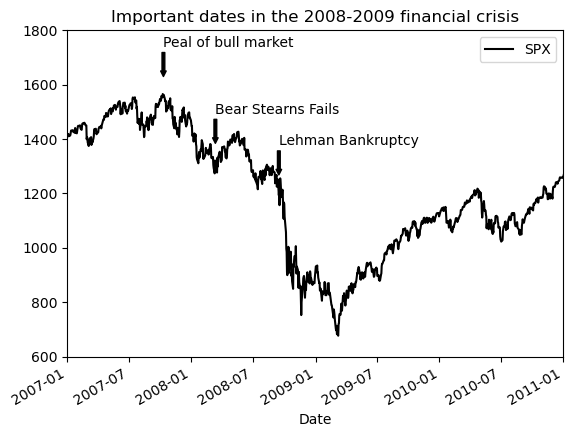

In [7]:
from datetime import datetime
import pandas as pd

fix, ax = plt.subplots()
# index_col=0表示第一列为日期        parse_dates=True表示将日期转换为datetime格式
data = pd.read_csv("../examples/spx.csv", index_col=0, parse_dates=True)
# 提取SPX列以DF的方式存入spx
spx = pd.DataFrame(data["SPX"])
#print(spx)
# 将SPX指数的数据绘制在坐标轴 ax 上
spx.plot(ax=ax, color="black")

# 列表包含年份和事件描述
crisis_data = [
    (datetime(2007, 10, 11), "Peal of bull market"),
    (datetime(2008, 3, 12), "Bear Stearns Fails"),
    (datetime(2008, 9, 15), "Lehman Bankruptcy")
]

for date, label in crisis_data:
    print(data, label)
    # 返回接近指定日期date的SPX指数值，values[0]提取该值
    value_at_date = spx.asof(date).values[0]   # 获取特定日期的 SPX，每个date行中的第一个值
    # annotate在图表中标注事件，xy设置箭头指向的坐标位置，xytest设置文本显示的位置
    ax.annotate(label, xy=(date, value_at_date + 75),  # 日期和相应 SPX 指数值加上 75 以避免重叠
                xytext=(date, value_at_date + 225),  # 同样将 SPX 指数值加 225
                # 定义箭头的样式，颜色宽度长度
                arrowprops=dict(facecolor="black", headwidth=4, width=2,
                                headlength=4),
                # 空制文本的对齐方式
                horizontalalignment="left", verticalalignment="top")

# 设置 x 轴的范围，起始时间为2007年1月1日，结束时间为2011年1月1日，只显示这区间的图像
ax.set_xlim([datetime(2007, 1, 1), datetime(2011, 1, 1)])
# 设置 y 轴的范围，在600~1800之间
ax.set_ylim([600, 1800])

# 设置图标标题
ax.set_title("Important dates in the 2008-2009 financial crisis")

书中的spx.asof(data)写法不对，因为 .asof() 方法期望接收一个单一的日期时间值（或一组日期）,而不是整个 DataFrame data。


应该修改为value_at_date = spx.asof(date).values[0]去获取特定的spx值

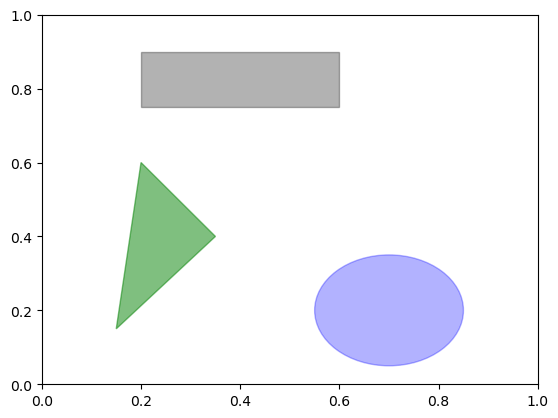

In [163]:
# 绘制图形，创建补丁对象，将其传递给ax.add_patch,将其添加到子图 ax 中
# 由三个补丁生成的图
fig, ax = plt.subplots()
rect = plt.Rectangle((0.2, 0.75), 0.4, 0.15, color="black", alpha=0.3)
cric = plt.Circle((0.7, 0.2), 0.15, color="blue", alpha=0.3)
pgon = plt.Polygon([[0.15, 0.15], [0.35, 0.4], [0.2, 0.6]],
                   color="green", alpha=0.5)

ax.add_patch(rect)
ax.add_patch(cric)
ax.add_patch(pgon)

#### 9.1.5 图片保存到文件  

保存文件：fig.savefig("xxx.svg", dpi=xxx)  
保存pdf的情况下fig.savefig("xxx.pdf", dpi=xxx)  


fig.savefig的一些选项：|
![jupyter](9.3.png)

#### 9.1.6 matplotlib 配置  
matplotlib自带一些配色方案，以及为生成出版高质量的图片而设定的默认配置信息。  


几乎所有默认配置都能通过一组全局参数进行自定义，可以管理图片大小、子图边距、配色方案、字体大小、网格类型等  


rc方法是通过py编程修改配置的途径之一

In [9]:
# 将全局的图像默认大小设置为10×10
plt.rc("figure", figsize=(10, 10))

In [11]:
# 当前配置存储于字典plt.rcParams,调用plt.rcdefaults()函数即可恢复默认值
plt.rcdefaults()

In [13]:
# rc的第一个参数是想要自定义的组件，比如："figure","axes","xtick","ytick","grid","legend"
plt.rc("font", family="monospace", weight="bold", size=8)

此代码设置 Matplotlib 图形中的字体属性。   
family="monospace" 指定字体为等宽字体，weight="bold" 使字体加粗，而 size=8 设置字体大小为 8。

要了解更多的自定义以及全部选项，请查阅matplotlib的配置文件matplotlibrc（位于路
径matplotlib/mpl-data）



。如果对该文件进行了自定义，并将其放在你自已的home路
下，并重命名为.matplotlibrc，则每次使用matplotlib时就会加载该文件。

### 9.2 使用pandas和seaborn绘图   

matplotlib实际是比较底层的工具。  
基本图形：线形图、柱状图、箱型图、散点图、等高线图

#### 9.2.1 线形图

Series 和 DF 都有一个plot属性，用于绘制基本图表，默认生成的是直线。

<Axes: >

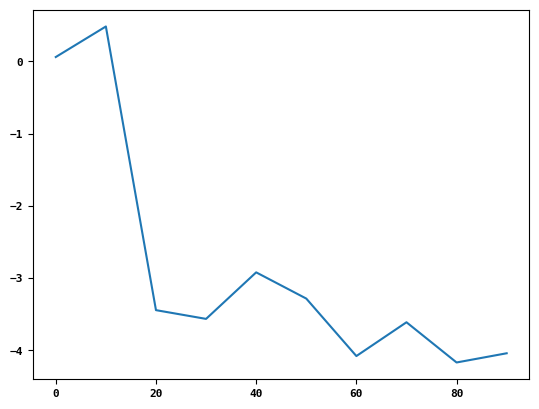

In [17]:
s = pd.Series(np.random.standard_normal(10).cumsum(), index=np.arange(0, 100, 10))
s.plot()

该Series对象的索引会被传给matplotlib，并用于绘制x轴。



可以通过use_index=False禁用该功能。  



x轴的刻度和界限可以通过xticks和xlin选项进行调节，y轴用yticks和ylin调节。 


Series.plot方法的参数  

![jupyter](9.4.png)

pandas的大部分绘图方法都接收一个可选的ax参数，它可以是matplotlib的子图对象。  




这使你能够在网格布局中更为灵活地处理子图的位置。

<Axes: >

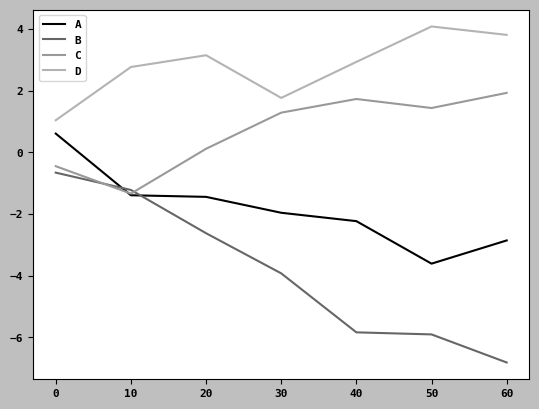

In [77]:
# DF 的 plot方法将各列绘制成同一子图中不同的线，并自动创建图例：
# cumsum(0)是沿着 x 轴进行累加，10行四列，都是向右累加
df = pd.DataFrame(np.random.standard_normal((10, 4)).cumsum(0),
                  columns=["A", "B", "C", "D"],
                  # 生成一个从0开始到100步长为10的数组[0, 10, 20...]作为索引
                  index=np.arange(0, 100, 10))
plt.style.use('grayscale')
df.iloc[:7, :].plot()

**为什么df.iloc[:7, :].plot()没有画出前七行数据的图？**   
因为plot默认是绘制出所有列的图，这样只是对df进行切片，只输出前七行的值，所以绘图时到60就已经停止了  



要想按行输出，必须进行转置

<Axes: >

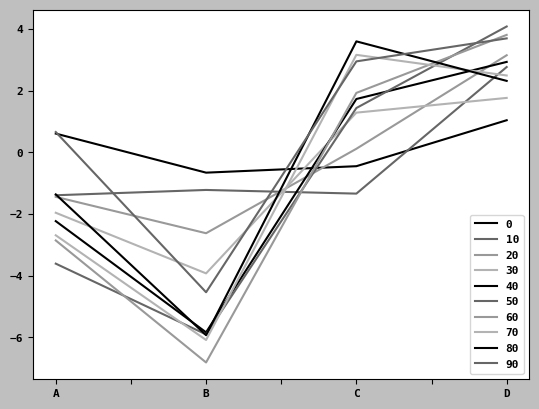

In [81]:
# 按行输出
df.T.plot()

专属DF的plot参数  

![jupyter](9.5.png)

#### 9.2.2 柱状图  
plot.bar() 和 plot.barh()分别用于绘制水平柱状图和垂直柱状图。

Text(0.5, 1.0, '水平图')

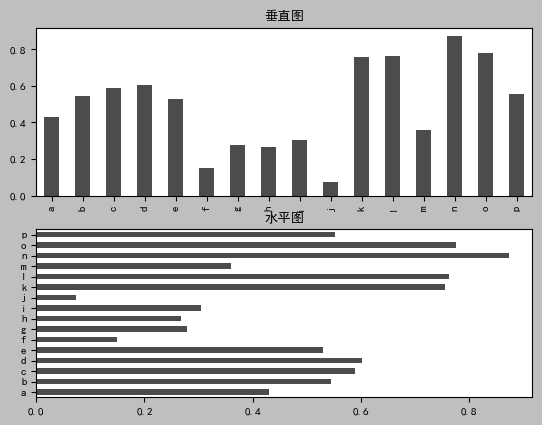

In [99]:
# Series 和 DF 索引作为 x 轴 或 y 轴的刻度
fig, axes = plt.subplots(2, 1)    # 创建 2 行 1 列共两个子图 
data = pd.Series(np.random.uniform(size=16), index=list("abcdefghijklmnop"))  # 索引是要一个能迭代的集合
data.plot.bar(ax=axes[0], color="black", alpha=0.7)
axes[0].set_title("垂直图")
data.plot.barh(ax=axes[1], color="black", alpha=0.7)
axes[1].set_title("水平图")

In [101]:
# 对于DF,柱状图会将每一行的值分为一组，并排显示
df = pd.DataFrame(np.random.uniform(size=(6, 4)),
                  index=["one", "two", "three", "four", "five", "six"],
                  columns=pd.Index(["A", "B", "C", "D"], name="Genus"))
df

Genus,A,B,C,D
one,0.675801,0.375604,0.325908,0.333472
two,0.757399,0.836555,0.633498,0.587962
three,0.335514,0.234853,0.905078,0.095150
four,0.140127,0.390716,0.173806,0.018532
five,0.976627,0.046976,0.254328,0.537075
six,0.440257,0.489898,0.436449,0.153901


<Axes: >

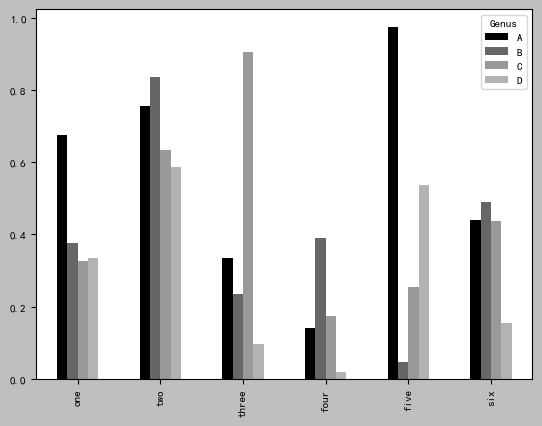

In [107]:
df.plot.bar()  # Genus被作为图例的标题

<Axes: xlabel='Genus'>

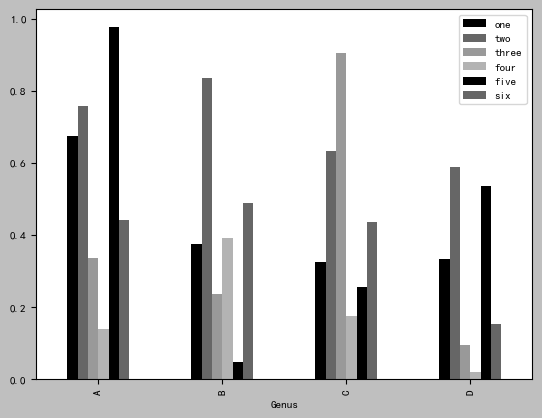

In [105]:
df.T.plot.bar()

<Axes: >

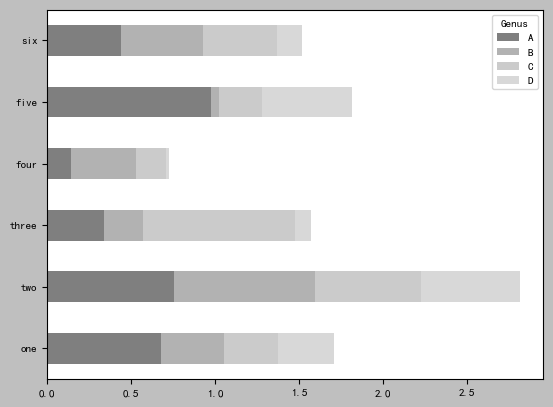

In [109]:
# 传入 stacked=True， 即可为DF生成堆积柱状图，这样每行的值就会水平堆积在一起
df.plot.barh(stacked=True, alpha=0.5)

<Axes: xlabel='A,B,C,D'>

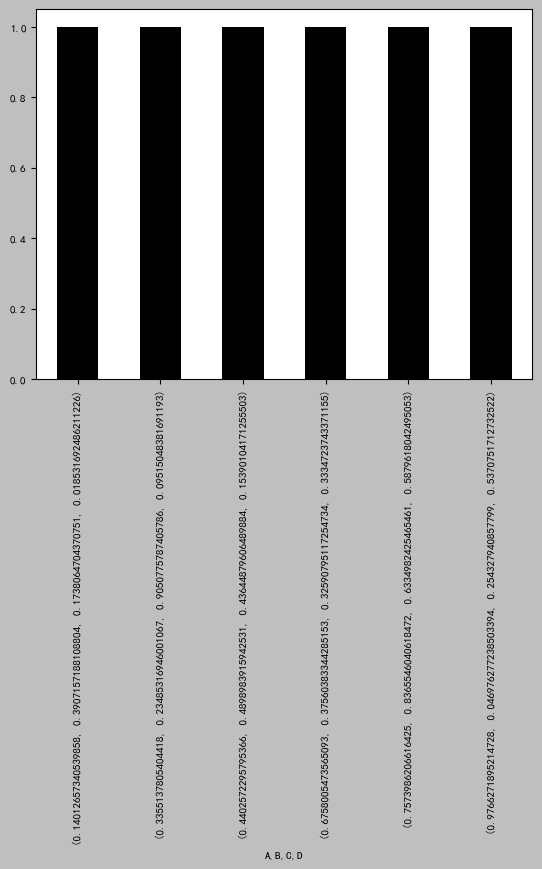

In [117]:
# value_counts()可以对Series的各值出现频率进行可视化非常有效
df.value_counts().plot.bar()

看一个有关餐厅小费的数据集。假设我们想要做一张堆积柱状图，以展示每天各种聚会规模的数据点的百分比。



用read_csv加载数据，然后根据日期和聚会规模创建一张交叉表。



使用pandas.crosstab函数可以便利地从两个DataFrame列计算出简单的频率表：

In [120]:
tips = pd.read_csv("../examples/tips.csv")
tips.head()

,total_bill,tip,smoker,day,time,size
0,16.99,1.01,No,Sun,Dinner,2
1,10.34,1.66,No,Sun,Dinner,3
2,21.01,3.50,No,Sun,Dinner,3
3,23.68,3.31,No,Sun,Dinner,2
4,24.59,3.61,No,Sun,Dinner,4


In [126]:
# 简单的频率计算
# 交叉表（crosstab）生成一个表格，行是 day，列是 size，单元格中的值是对应组合的计数。
party_counts = pd.crosstab(tips["day"], tips["size"])
# 确保表格的行顺序为指定的顺序，即从 Thur 到 Sun。
party_counts = party_counts.reindex(index=["Thur", "Fri", "Sat", "Sun"])
# 每个单元格的值表示在该特定日期选择该人数的顾客数量。
party_counts

size,1,2,3,4,5,6
day,,,,,,
Thur,1,48,4,5,1,3
Fri,1,16,1,1,0,0
Sat,2,53,18,13,1,0
Sun,0,39,15,18,3,1


In [130]:
# 去除一人聚餐和六人聚餐
party_counts = party_counts.loc[:, 2:5]
party_counts

size,2,3,4,5
day,,,,
Thur,48,4,5,1
Fri,16,1,1,0
Sat,53,18,13,1
Sun,39,15,18,3


In [132]:
# 正态化，使各行的和为 1，并生成列表
party_pcts = party_counts.div(party_counts.sum(axis="columns"),
                                axis="index")
party_pcts

size,2,3,4,5
day,,,,
Thur,0.827586,0.068966,0.086207,0.017241
Fri,0.888889,0.055556,0.055556,0.000000
Sat,0.623529,0.211765,0.152941,0.011765
Sun,0.520000,0.200000,0.240000,0.040000


<Axes: xlabel='day'>

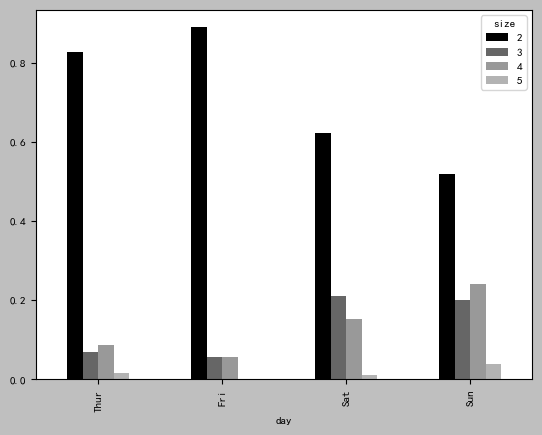

In [134]:
party_pcts.plot.bar()

<Axes: xlabel='day'>

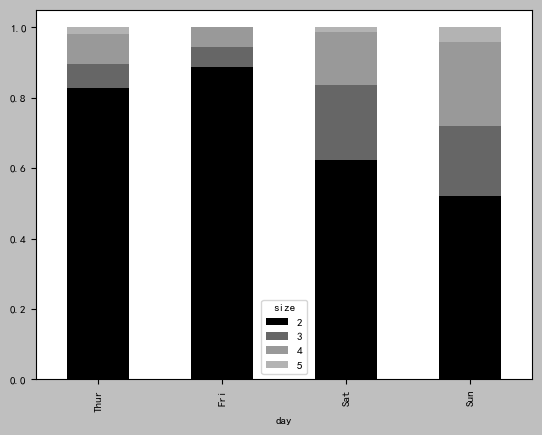

In [136]:
party_pcts.plot.bar(stacked=True)

明显看出来周末时聚会规模会变大

**为什么要进行正态化？**  



对数据进行正态化（或标准化）可以帮助我们更好地理解数据的分布和相对比例。

在你的代码中，party_pcts = party_counts.div(party_counts.sum(axis="columns"), axis="index") 是在计算每一天不同用餐人数的比例（百分比），而不是绝对计数。   



这种操作有几个好处：

比较不同类别的相对大小：正态化可以让你更容易比较不同天的用餐人数分布。例如，如果某一天的总人数比其他天少，绝对计数可能会误导你，而相对比例能提供更清晰的比较视角。   

消除样本量的影响：在分析中，样本量的大小会影响绝对计数。通过计算比例，你可以消除这种影响，使得分析更具普适性。   

更清晰的可视化：在绘制图表时，使用比例而不是绝对数值可以使得不同类别（如不同用餐人数）在同一图表中更易于比较，特别是当样本量差异较大时。    

识别模式：通过观察各类别的相对比例，可能更容易识别趋势或模式，例如某一天更多人选择小组用餐或单人用餐。   

In [140]:
# seaborn 可视化每天的小费比例：
import seaborn as sns

tips["tip_pct"] = tips["tip"] / (tips["total_bill"] - tips["tip"])
tips.head()

,total_bill,tip,smoker,day,time,size,tip_pct
0,16.99,1.01,No,Sun,Dinner,2,0.063204
1,10.34,1.66,No,Sun,Dinner,3,0.191244
2,21.01,3.50,No,Sun,Dinner,3,0.199886
3,23.68,3.31,No,Sun,Dinner,2,0.162494
4,24.59,3.61,No,Sun,Dinner,4,0.172069


<Axes: xlabel='tip_pct', ylabel='day'>

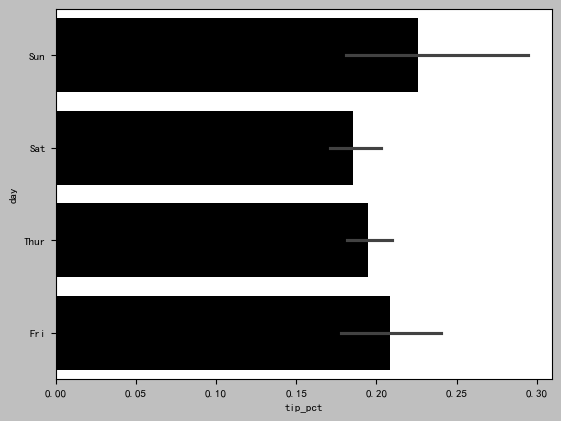

In [157]:
# errorbar=None 去掉误差条
sns.barplot(x="tip_pct", y="day", data=tips, orient="h")  # 手动误差条errorbar="sd"

**tips那么多数据，sns怎么处置这些数据并绘制？**

比如 x 轴的tip_pct就是将day按组分后进行求平均  


对于 y 轴的每一个独特值（即每一个用餐日，如“Thur”、“Fri”、“Sat”、“Sun”），Seaborn 会计算所有对应行的 tip_pct 的平均值。这意味着，如果某一天有多笔消费记录，Seaborn 会将这些记录的小费比例加起来，然后计算平均值。

sns.barplot：这是 Seaborn 中用于绘制条形图的函数。  



x="tip_pct"：指定 x 轴为小费比例（tip_pct）。   



y="day"：指定 y 轴为用餐日（day）。




data=tips：指定数据源为 tips DataFrame。此时每天的消费比例已经全部算好，之前的count_values()




orient="h"：将条形图设置为水平显示。


seaborn的绘制需要data参数，可以是DF。其他参数用于引用列名。  
因为day的每个值有多次观测值，柱状图的值是tip_pct的平均值。绘制在柱状图上的黑线表示95%的置信区间，可以通过参数调配。

<Axes: xlabel='tip_pct', ylabel='day'>

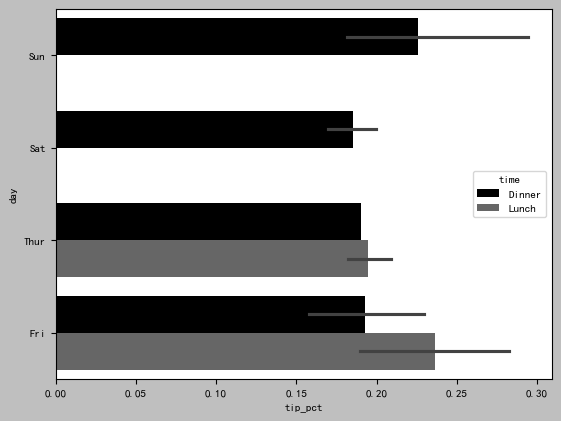

In [164]:
# seaborn.barplot可以选颜色hue，可以通过不同颜色将数值分离：
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

In [168]:
# seaborn已经自动修改图形的美观性：默认调色板、图形背景和网格颜色。可以用seaborn.set_style在不同的图形外观间切换
sns.set_style("whitegrid")

<Axes: xlabel='tip_pct', ylabel='day'>

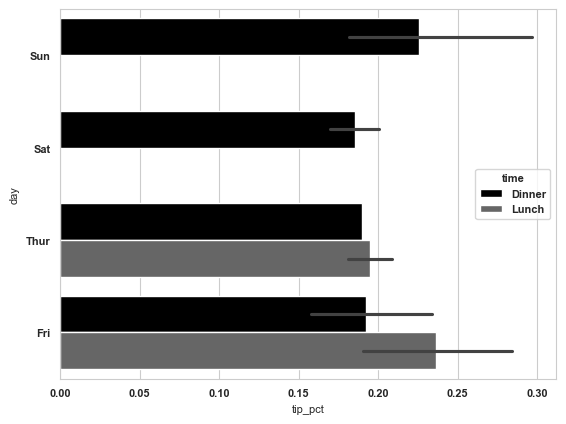

In [174]:
# 对于黑白印刷可以设置为灰度调色板
sns.set_style("whitegrid")
sns.barplot(x="tip_pct", y="day", hue="time", data=tips, orient="h")

#### 9.2.3 直方图和密度图  
直方图是一种可以对值频率进行离散化显示的柱状图。数据点被拆分到离散且间隔均匀的箱中，并绘制各箱中数据点的数量。

<Axes: ylabel='Frequency'>

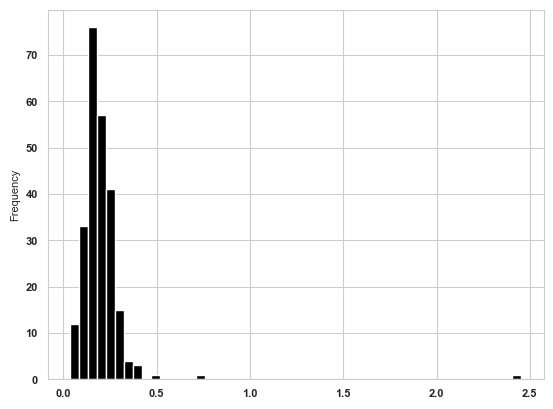

In [178]:
# 使用plot.hist方法生成“消费占消费总额百分比”的直方图
tips["tip_pct"].plot.hist(bins=50)

**密度图**：通过计算“可能会产生观测数据的连续概率分布估计”得到的，一般过程是将该分布近似为“核”的混合，诸如正态分布之类的简单分布。因此，密度图也称作核密度估计（KDE）图。2）：

Text(0.5, 1.0, '小费占消费总额百分比密度图')

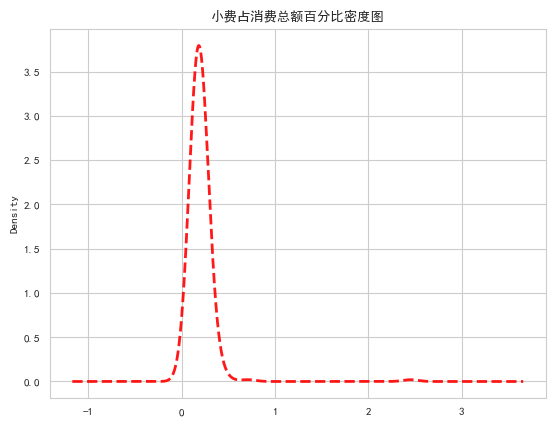

In [249]:
# 使用plot.density生成一幅常规混合正态分布估计的密度图
tips["tip_pct"].plot.density(bw_method=0.5, color="r", linestyle='--', linewidth=2, alpha=0.9)

plt.title("小费占消费总额百分比密度图")

密度图需要用Scipy  
seaborn的histplot方法绘制直方图和密度图更简便，还可以同时画出直方图和连续密度估计图。

<Axes: xlabel='values', ylabel='Count'>

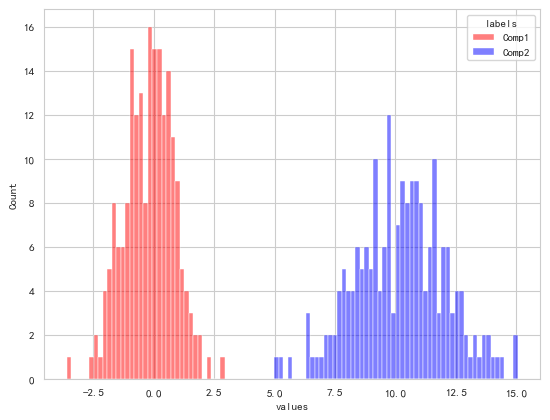

In [251]:
# 由两个不同的标准正态分布组成的二项分布
comp1 = np.random.standard_normal(200)
comp2 = 10 + 2 * np.random.standard_normal(200)

# concatenate 数据合并，默认按行axis=0
values = pd.Series(np.concatenate([comp1, comp2]))

# 区分箱值
labels = ['Comp1'] * 200 + ['Comp2'] * 200
df = pd.DataFrame({'values': values, 'labels': labels})

                                            # palette 定义图形颜色参数
sns.histplot(data=df, x='values', hue='labels', bins=100, palette={'Comp1': 'r', 'Comp2': 'b'})

# 书中写法无法辨别前200 和后200 的区别
# sns.histplot(values, bins=100, color="r")

#### 9.2.4 散点图、点图  
点图或散点图是观察两个一维数据序列之间的关系的有效方式。

In [230]:
# 回归分析大头
macro = pd.read_csv("../examples/macrodata.csv")
data = macro[["cpi", "m1", "tbilrate", "unemp"]]
             # 取对数   计算差分   删除带有Na值的行
trans_data = np.log(data).diff().dropna()

trans_data.tail()

,cpi,m1,tbilrate,unemp
198,-0.007904,0.045361,-0.396881,0.105361
199,-0.021979,0.066753,-2.277267,0.139762
200,0.002340,0.010286,0.606136,0.160343
201,0.008419,0.037461,-0.200671,0.127339
202,0.008894,0.012202,-0.405465,0.042560


在 Pandas 中，DataFrame 和 Series 都有 diff() 方法。它可以用来计算当前行与前一行之间的差值。第一行没差分，因为前面没有数


直接是减去前一个数，比如数组[1, 2, 4, 7, 11] 的差分就是[Na, 1, 2, 3, 4]



在 Pandas 中，diff() 可用于数据框和序列，计算相邻行之间的差值。  
在 NumPy 中，np.diff() 用于计算数组的差分。

Text(0.5, 1.0, 'Changesin log(m1) versus log(unemp)')

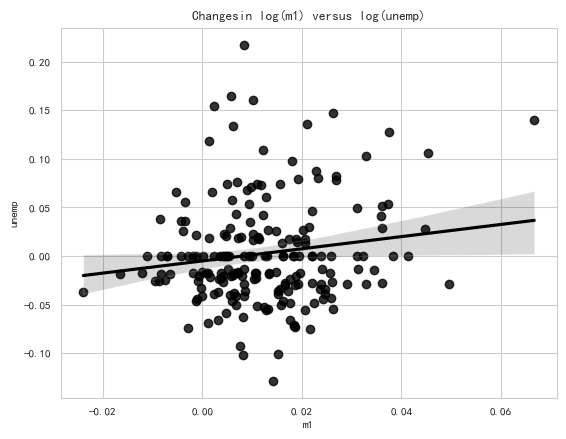

In [253]:
# 使用 seaborn 中的 regplot 方法生成散点图，并添加拟合直线：
ax = sns.regplot(x="m1", y="unemp", data=trans_data)
ax.set_title("Changesin log(m1) versus log(unemp)")

探索性数据分析工作中，同时观察一组变量的散点图非常有意义，也被称为是成对图或散点图矩阵。  



从0开始创建这样的图很费功夫，所以seaborn提供了便捷的 pairplot 函数，  
该函数支持在对角线上放置每个变量的直方图或密度估计。

diag_kind="kde"：指定对角线上的图形类型为核密度估计图（KDE），可以更好地显示数据的分布。   



plot_kws={"alpha": 0.2}：传递给每个散点图的额外关键字参数，这里设置了透明度为 0.2，以便更好地可视化重叠数据点。

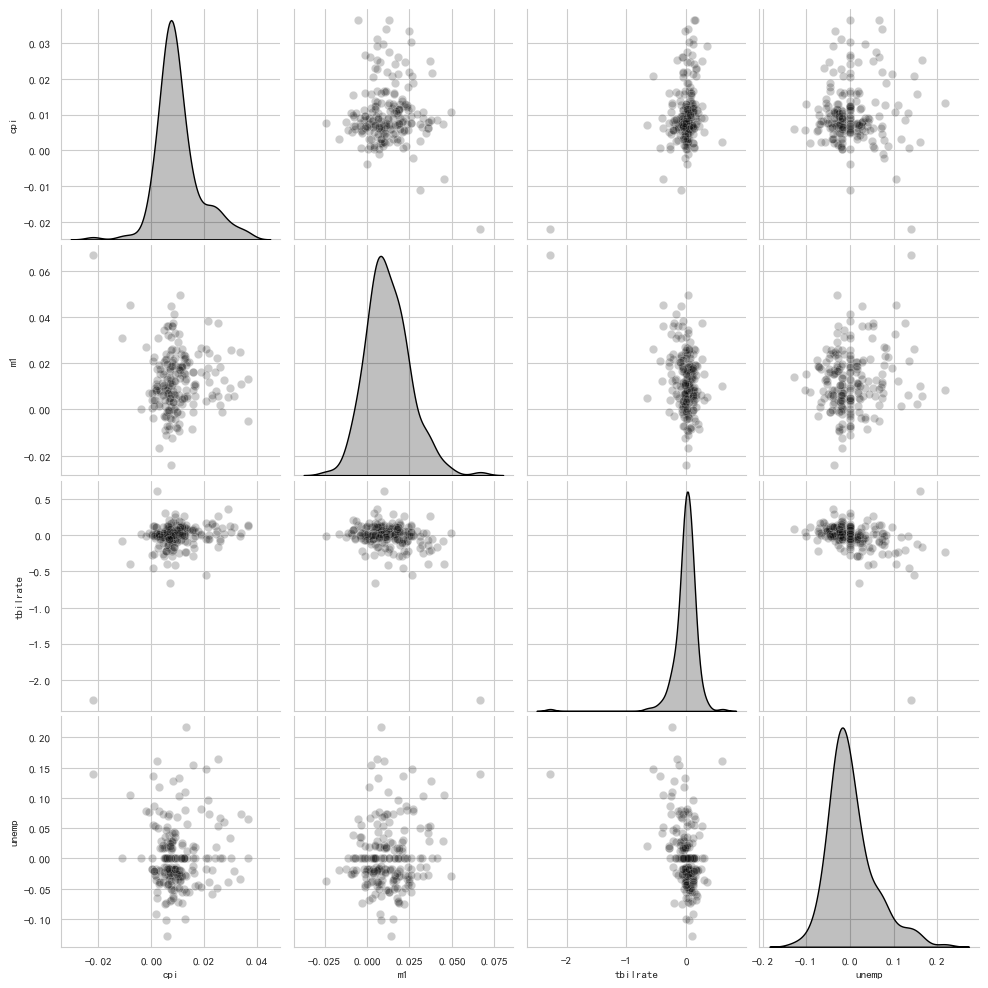

In [257]:
# statsmodels macro 数据的成对图矩阵
sns.pairplot(trans_data, diag_kind="kde", plot_kws={"alpha": 0.2})

#### 9.2.5 分面网格和分类数据  
**要是数据集有额外的分组维度，该怎么办呢？**  



对于有多个分类变量的数据，一种可视化方法是使用分面网格。  



分面网格是一种二维绘图布局，它根据特定变量所具有的不同值，将数据在每个轴上的绘图中进行分割。

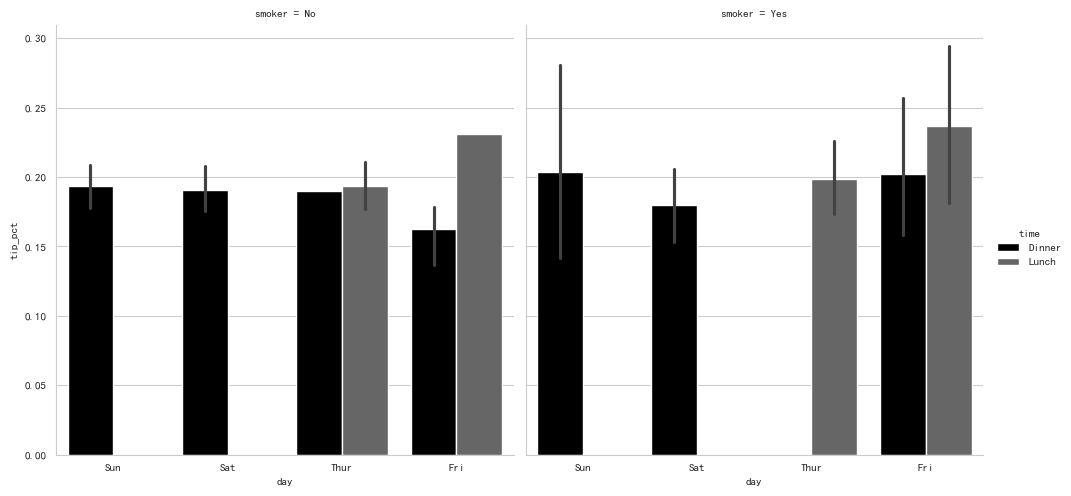

In [266]:
# seaborn有一个实用的内置函数catplot，可以简化制作多种分面图
# 按照天/时间/吸烟者的消费百分比
sns.catplot(x="day", y="tip_pct", hue="time", col="smoker",
            kind="bar", data=tips[tips.tip_pct < 1])